# Multi-Domain Correlation Analysis Validation

Evaluate correlations among topic proportions, sentiment metrics, clustering features, and demographic variables.

In [1]:
%pip install -U pandas geopandas numpy scikit-learn matplotlib seaborn shapely

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 5.7 MB/s eta 0:00:03
   ---- ----------------------------------- 1.3/12.6 MB 3.5 MB/s eta 0:00:04
   --------- ------------------------------ 3.1/12.6 MB 6.0 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.6 MB 8.2 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.6 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 11.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.5 which is incompatible.
numba 0.61.0 requires numpy<2.2,>=1.24, but you have numpy 2.2.5 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.


In [2]:
import yaml
import pandas as pd
import numpy as np
import geopandas as gpd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

In [16]:
# Load config and precomputed data
with open('../../config.yaml') as f:
    cfg = yaml.safe_load(f)
biz = gpd.read_file(f"../../precomputed/businesses.geojson").to_crs(epsg=4326)
clusters = gpd.read_file(f"../../precomputed/clusters.geojson").to_crs(epsg=4326)
zip_demo = gpd.read_file(f"../../precomputed/zip_demo.geojson").to_crs(epsg=4326)


In [18]:
# Attach demographics via spatial join
demog_cols = [c for c in zip_demo.columns if c not in [
        'CODE','geometry','centroid_x','centroid_y',
        'OBJECTID','COD','Shape__Area','Shape__Length',
        'unnamed:_0_x','age','unnamed:_0_y','unnamed:_0']]
zip_demo_sel = zip_demo[demog_cols + ['geometry']]
biz = gpd.sjoin(biz, zip_demo_sel, how='left', predicate='within')
biz = biz.drop(columns=['index_right'])

In [ ]:
# Merge cluster-level metrics
clusters_sel = clusters[[
    "cluster_id",
    "avg_sentiment", "avg_subjectivity", "avg_stars", "business_count",
    "geometry"
]]
biz = gpd.sjoin(
    biz,
    clusters_sel,
    how="left",
    predicate="within"
)
biz = biz.drop(columns=["index_right"])

In [ ]:
# Compute business-level topic proportions
df_rev = pd.read_parquet("../../datasets/cleaned_datasets/demographic_infused_philly_c.parquet")
df_rev = df_rev[df_rev['clean_text'].notna()]
vectorizer = TfidfVectorizer(stop_words='english', max_df=cfg['lda_max_df'], min_df=cfg['lda_min_df'])
tfidf = vectorizer.fit_transform(df_rev['clean_text'].tolist())
lda = LatentDirichletAllocation(n_components=cfg['num_topics'], random_state=42)
lda.fit(tfidf)
proportions = lda.transform(tfidf)
for i in range(cfg['num_topics']):
    df_rev[f'topic_{i}'] = proportions[:, i]
biz_topics = df_rev.groupby('business_id')[[f'topic_{i}' for i in range(cfg['num_topics'])]].mean().reset_index()
biz = biz.merge(biz_topics, on='business_id', how='left')


In [25]:
# Select numeric features for correlation
numeric_cols = biz.select_dtypes(include=['number']).columns.tolist()
corr_df = biz[numeric_cols].dropna()


In [26]:
# Compute Pearson and Spearman correlation matrices
pearson_corr = corr_df.corr(method='pearson')
spearman_corr = corr_df.corr(method='spearman')
print('Pearson Correlation Matrix')
display(pearson_corr)
print('Spearman Correlation Matrix')
display(spearman_corr)


Pearson Correlation Matrix


,latitude,longitude,sentiment_score,subjectivity_score,stars_rev,total_population_left,under_5_years_left,5_to_9_years_left,10_to_14_years_left,15_to_19_years_left,...,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9
latitude,1.000000,0.665946,-0.122817,-0.040480,-0.127335,0.228641,0.373298,0.342051,0.395200,0.027698,...,-0.059407,-0.033499,0.016651,0.166928,-0.096969,-0.075033,-0.047218,0.090813,-0.051570,0.027814
longitude,0.665946,1.000000,-0.127047,-0.043223,-0.122852,0.245240,0.387285,0.337619,0.412829,-0.089668,...,-0.053805,-0.024291,0.005566,0.138261,-0.065484,-0.078232,-0.045408,0.097849,-0.044635,0.001997
sentiment_score,-0.122817,-0.127047,1.000000,0.196393,0.764306,-0.093784,-0.115988,-0.144079,-0.145559,-0.059108,...,0.118436,-0.080940,0.126311,-0.398308,-0.108852,0.202111,0.169073,-0.097782,0.193987,0.069373
subjectivity_score,-0.040480,-0.043223,0.196393,1.000000,0.243598,-0.029312,-0.043753,-0.050151,-0.053692,0.009077,...,0.087027,-0.009424,0.073274,-0.029396,-0.068564,0.130765,0.108745,-0.144434,0.108287,-0.031708
stars_rev,-0.127335,-0.122852,0.764306,0.243598,1.000000,-0.070233,-0.079151,-0.118124,-0.118883,-0.070220,...,0.096872,-0.087280,0.143774,-0.437067,-0.172434,0.165680,0.127244,-0.005104,0.190288,0.113419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
topic_5,-0.075033,-0.078232,0.202111,0.130765,0.165680,-0.032929,-0.051160,-0.054184,-0.060728,-0.002655,...,-0.035141,-0.109302,0.056526,-0.034971,-0.165561,1.000000,-0.000948,-0.260526,0.037165,-0.192467
topic_6,-0.047218,-0.045408,0.169073,0.108745,0.127244,-0.029454,-0.051475,-0.039104,-0.049866,0.009840,...,0.048499,-0.097531,-0.053118,-0.011160,-0.177692,-0.000948,1.000000,-0.213342,0.029067,-0.157702
topic_7,0.090813,0.097849,-0.097782,-0.144434,-0.005104,0.056858,0.068900,0.061920,0.076259,0.008192,...,-0.173854,-0.046329,-0.219938,-0.232203,-0.232759,-0.260526,-0.213342,1.000000,-0.165512,-0.138425
topic_8,-0.051570,-0.044635,0.193987,0.108287,0.190288,-0.063091,-0.047162,-0.063789,-0.064213,-0.065572,...,-0.004440,-0.037302,-0.031874,-0.084323,-0.028956,0.037165,0.029067,-0.165512,1.000000,-0.097656


Spearman Correlation Matrix


,latitude,longitude,sentiment_score,subjectivity_score,stars_rev,total_population_left,under_5_years_left,5_to_9_years_left,10_to_14_years_left,15_to_19_years_left,...,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9
latitude,1.000000,0.494463,-0.116891,-0.039005,-0.120534,0.155936,0.264923,0.228259,0.358287,0.285534,...,-0.023721,-0.056833,0.013131,0.118813,-0.100892,-0.052225,-0.019340,0.054039,-0.077863,0.007195
longitude,0.494463,1.000000,-0.067218,-0.043093,-0.057802,0.202146,0.347719,0.177891,0.300077,0.137615,...,-0.016392,-0.036324,-0.020480,0.051361,-0.079252,-0.060956,-0.018630,0.056325,-0.035745,0.000340
sentiment_score,-0.116891,-0.067218,1.000000,0.247493,0.744733,-0.075859,-0.084727,-0.130108,-0.146088,-0.148479,...,0.022481,-0.087381,0.035406,-0.387043,-0.109509,0.099782,0.074028,-0.123632,0.124348,0.003525
subjectivity_score,-0.039005,-0.043093,0.247493,1.000000,0.238862,-0.022793,-0.036173,-0.043223,-0.048945,-0.036253,...,0.241329,0.089794,0.225588,0.089359,-0.049766,0.264207,0.246777,-0.087721,0.241049,0.044448
stars_rev,-0.120534,-0.057802,0.744733,0.238862,1.000000,-0.045315,-0.040349,-0.101796,-0.116125,-0.128903,...,0.126433,0.003082,0.154662,-0.337412,-0.192965,0.144739,0.142820,0.054145,0.199383,0.128962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
topic_5,-0.052225,-0.060956,0.099782,0.264207,0.144739,0.008960,-0.014718,-0.010728,-0.024795,-0.017746,...,0.530655,0.222078,0.604690,0.396856,-0.060141,1.000000,0.568893,-0.175006,0.516842,0.055324
topic_6,-0.019340,-0.018630,0.074028,0.246777,0.142820,0.010051,-0.016150,-0.007570,-0.018183,-0.012906,...,0.652488,0.269665,0.551975,0.422973,-0.107434,0.568893,1.000000,-0.074421,0.587156,0.133086
topic_7,0.054039,0.056325,-0.123632,-0.087721,0.054145,0.035132,0.050044,0.040556,0.056722,0.042334,...,-0.052207,0.129195,-0.059415,-0.115825,-0.227322,-0.175006,-0.074421,1.000000,-0.018971,0.089710
topic_8,-0.077863,-0.035745,0.124348,0.241049,0.199383,-0.054229,-0.043392,-0.078287,-0.082053,-0.081608,...,0.521939,0.324671,0.482868,0.292603,0.008033,0.516842,0.587156,-0.018971,1.000000,0.223266


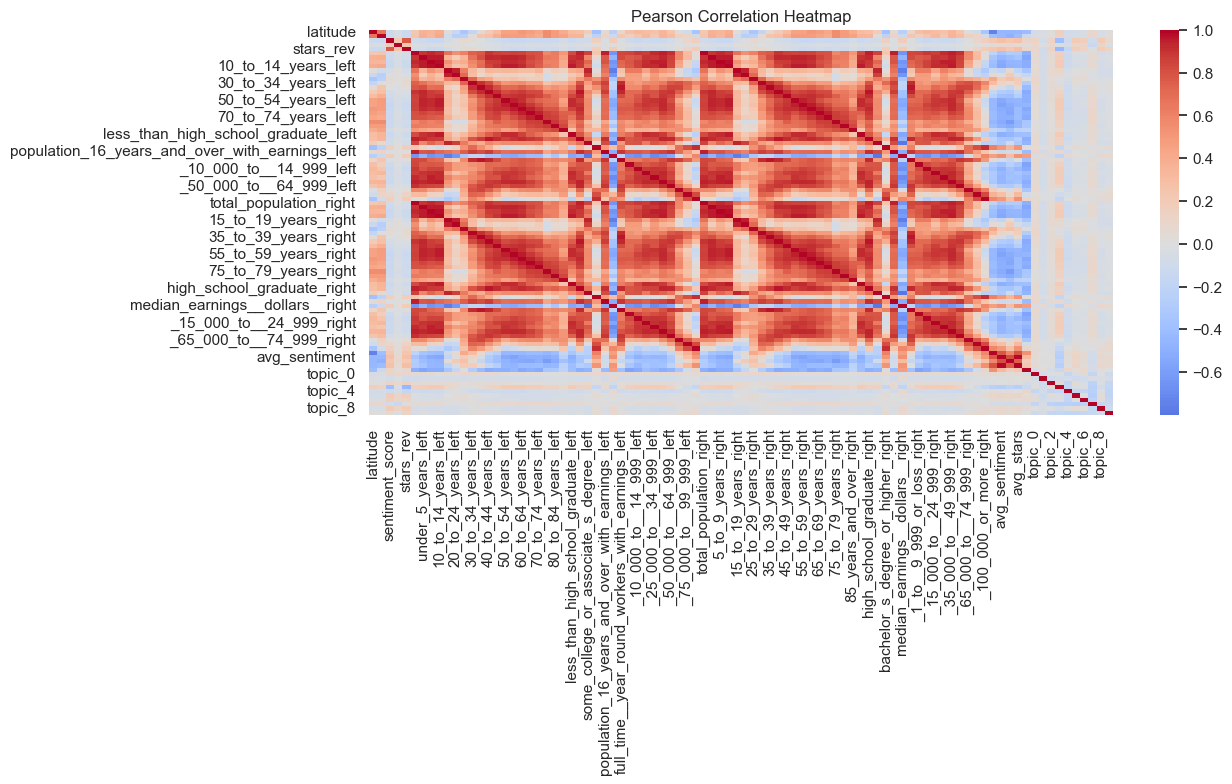

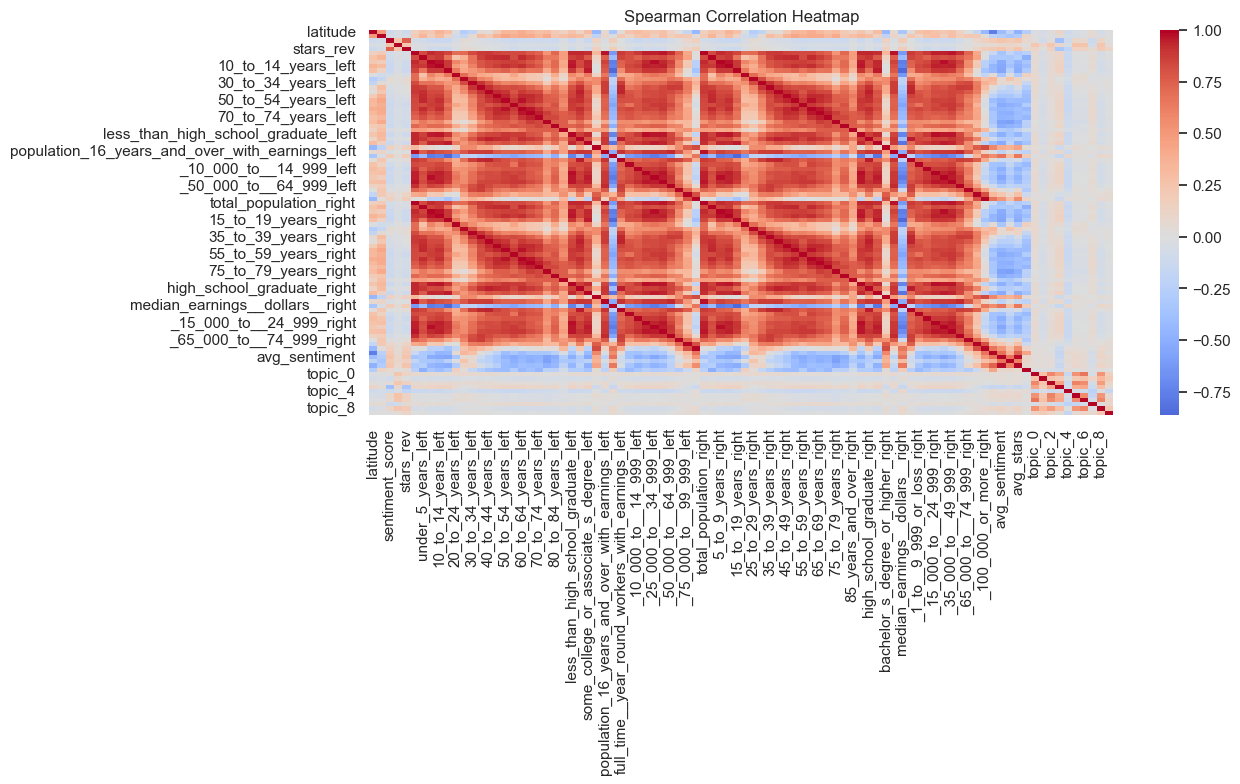

In [ ]:
import matplotlib as mpl
import re

mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'

def clean_label(s):
    return re.sub(r'[^0-9a-zA-Z_]', '_', s)

pearson_clean = pearson_corr.copy()
pearson_clean.index  = [clean_label(c) for c in pearson_clean.index]
pearson_clean.columns = [clean_label(c) for c in pearson_clean.columns]

spearman_clean = spearman_corr.copy()
spearman_clean.index  = [clean_label(c) for c in spearman_clean.index]
spearman_clean.columns = [clean_label(c) for c in spearman_clean.columns]

plt.figure(figsize=(12,5))
sns.heatmap(pearson_clean, cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap')
plt.show()

plt.figure(figsize=(12,5))
sns.heatmap(spearman_clean, cmap='coolwarm', center=0)
plt.title('Spearman Correlation Heatmap')
plt.show()